<a href="https://colab.research.google.com/github/weijenchen519/python-data-analysis/blob/main/cheerleader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#讀取檔案
import pandas as pd
from google.colab import drive
drive.mount('/content/gdrive')
cheerleader = pd.read_excel("/content/gdrive/My Drive/cheerleader.xlsx")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
import numpy as np
cheerleader.info()
# 以NAN取代空值
cheerleader.replace('', np.nan, inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   姓名         37 non-null     object        
 1   身高         37 non-null     int64         
 2   體重         20 non-null     float64       
 3   生日         37 non-null     datetime64[ns]
 4   MBTI       30 non-null     object        
 5   加盟年分       37 non-null     int64         
 6   應援KBO球隊    23 non-null     object        
 7   來台應援球種     37 non-null     object        
 8   經營Youtube  37 non-null     int64         
 9   開直播        37 non-null     int64         
 10  經紀公司       33 non-null     object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 3.3+ KB


In [54]:
#先提取一些想分析的資料
cheerleader_extract = cheerleader[['姓名','身高','生日','MBTI','加盟年分','來台應援球種','經營Youtube','開直播']]
cheerleader_extract.head()

,姓名,身高,生日,MBTI,加盟年分,來台應援球種,經營Youtube,開直播
0,李多慧,164,1999-08-04,ISTP,2023,棒球,1,0
1,權喜原,168,2004-03-07,INFP,2025,棒球,0,1
2,金娜妍,164,1999-05-07,ENFP,2025,棒球、籃球,1,1
3,李雅英,170,1992-02-09,ISFJ,2024,棒球、籃球,1,1
4,南珉貞,166,1997-09-08,ISTJ,2024,棒球、籃球,1,1


count     37.00
mean     167.78
std        2.62
min      163.00
25%      166.00
50%      168.00
75%      170.00
max      174.00
Name: 身高, dtype: float64


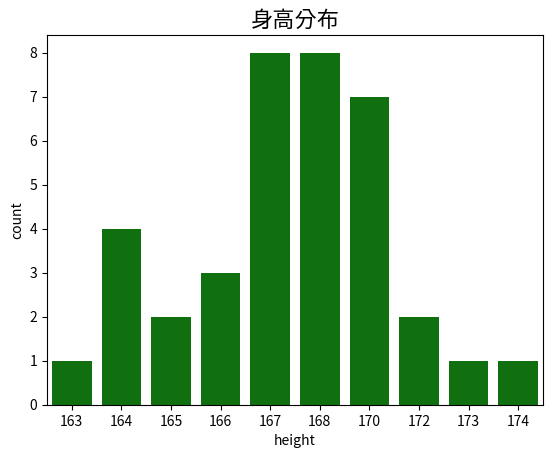

In [ ]:
#身高統計
cheerleader_extract['身高'].describe()
print(cheerleader_extract['身高'].describe().round(2))

# Set font to display Chinese characters
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data = cheerleader_extract ,x ='身高' ,color = 'green')
plt.title('身高分布',fontsize = 16)
plt.xlabel('height')
plt.show()

count    37.00
mean     25.89
std       3.53
min      20.00
25%      24.00
50%      25.00
75%      28.00
max      36.00
Name: 年齡, dtype: float64


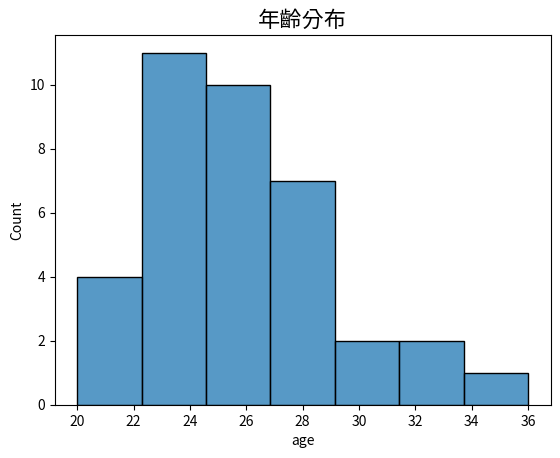

In [ ]:
#年齡分析
import pandas as pd
from datetime import date

#取得今天的日期
today = pd.to_datetime(date.today())

#計算年齡
def calculate_age(birth_date):
    return today.year - birth_date.year - ((today.month, today.day) < (birth_date.month, birth_date.day))

#將函式應用於整個欄位
cheerleader_extract.loc[:, '年齡'] = cheerleader_extract['生日'].apply(calculate_age)
cheerleader_extract.head()

#統計及製作分布圖
cheerleader_extract['年齡'].describe()
print(cheerleader_extract['年齡'].describe().round(2))

sns.histplot(cheerleader_extract['年齡'])
plt.title('年齡分布',fontsize = 16)
plt.xlabel('age')
plt.show()

星座
雙魚    6
金牛    5
天蠍    5
魔羯    5
水瓶    4
天坪    3
處女    3
獅子    2
雙子    2
射手    1
巨蟹    1
Name: count, dtype: int64


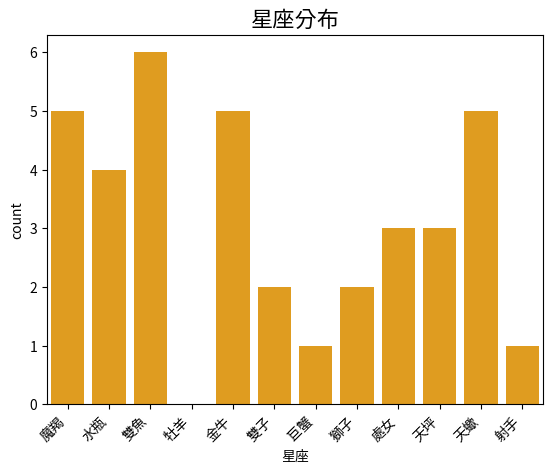

     姓名   身高         生日  MBTI  加盟年分 來台應援球種  經營Youtube  開直播  年齡  星座
1   權喜原  168 2004-03-07  INFP  2025     棒球          0    1  21  雙魚
9   河智媛  167 2002-02-22  ENTP  2025     棒球          0    0  23  雙魚
10  李丹妃  170 1989-03-08   NaN  2024  棒球、籃球          0    1  36  雙魚
11  邊荷律  164 1999-03-04  INFP  2024  棒球、籃球          1    1  26  雙魚
23  金裕娜  172 1996-03-03  ISTJ  2025     籃球          0    0  29  雙魚
30  李素泳  170 1999-03-04   NaN  2025  籃球、排球          1    1  26  雙魚


In [ ]:
#新增一欄名為星座
import pandas as pd
def zodiac (birth_date):
  month = birth_date.month
  day = birth_date.day
  if(month == 1 and day >= 20) or (month == 2 and day <= 18):
        return '水瓶'
  elif (month == 2 and day >= 19) or (month == 3 and day <= 20):
        return '雙魚'
  elif (month == 3 and day >= 21) or (month == 4 and day <= 19):
        return '牡羊'
  elif (month == 4 and day >= 20) or (month == 5 and day <= 20):
        return '金牛'
  elif (month == 5 and day >= 21) or (month == 6 and day <= 21):
        return '雙子'
  elif (month == 6 and day >= 22) or (month == 7 and day <= 22):
        return '巨蟹'
  elif (month == 7 and day >= 23) or (month == 8 and day <= 22):
        return '獅子'
  elif (month == 8 and day >= 23) or (month == 9 and day <= 22):
        return '處女'
  elif (month == 9 and day >= 23) or (month == 10 and day <= 23):
        return '天坪'
  elif (month == 10 and day >= 24) or (month == 11 and day <= 22):
        return '天蠍'
  elif (month == 11 and day >= 23) or (month == 12 and day <= 21):
        return '射手'
  elif (month == 12 and day >= 22) or (month == 1 and day <= 19):
        return '魔羯'
  else:
        return '日期錯誤'

# 應用函式並安全賦值給 '星座' 欄位
cheerleader_extract.loc[:,'星座'] = cheerleader_extract['生日'].apply(zodiac)
print(cheerleader_extract['星座'].value_counts())

#製圖
zodiac_order = [
    '魔羯', '水瓶', '雙魚', '牡羊',
    '金牛', '雙子', '巨蟹', '獅子',
    '處女', '天坪', '天蠍', '射手'
]
sns.countplot(data = cheerleader_extract, x= '星座',
              order = zodiac_order,color='orange')
plt.xticks(rotation=45, ha='right')
plt.title('星座分布',fontsize = 16)
plt.show()

#雙魚座人數最多，印出雙魚座
print(cheerleader_extract[cheerleader_extract['星座']=='雙魚'])

In [ ]:
# 步驟一：下載支持中文的字體
# 將字體文件 TaipeiSansTCBeta-Regular.ttf 下載到Colab運行環境中
!wget -O TaipeiSansTCBeta-Regular.ttf "https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download"

# 載入 Matplotlib 庫並新增字體
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.font_manager import fontManager

# 載入字體文件
fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')

# 設定 Matplotlib 參數，使用該字體
mpl.rcParams['font.sans-serif'] = ['Taipei Sans TC Beta']
mpl.rcParams['axes.unicode_minus'] = False # 解決負號亂碼問題

print("Matplotlib 中文字體已重新設定完成。")

--2025-11-13 06:38:39--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download
Resolving drive.google.com (drive.google.com)... 142.251.111.100, 142.251.111.102, 142.251.111.138, ...
Connecting to drive.google.com (drive.google.com)|142.251.111.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download [following]
--2025-11-13 06:38:39--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.16.132, 2607:f8b0:4004:c19::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.16.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================>]

來台應援球種
棒球、籃球       9
籃球          9
棒球          8
排球          6
籃球、排球       3
棒球、籃球、排球    2
Name: count, dtype: int64


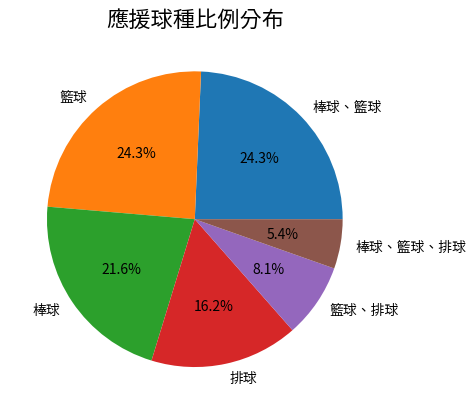

In [ ]:
sports_count = cheerleader_extract['來台應援球種'].value_counts()
print(sports_count)
plt.pie(sports_count, labels=sports_count.index,autopct = '%.1f%%')
plt.title('應援球種比例分布',fontsize = 16)
plt.show()

加盟年分
2023     3
2024     8
2025    26
Name: count, dtype: int64


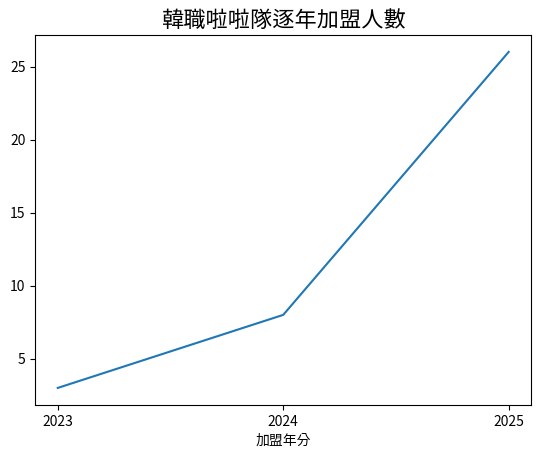

In [ ]:
#加盟年份

# Get the value counts for '加盟年分'
year_counts = cheerleader_extract['加盟年分'].value_counts().sort_index()
print(year_counts)

# Plot the value counts
plt.plot(year_counts.index, year_counts.values)
plt.xticks(year_counts.index.astype(int))
plt.title('韓職啦啦隊逐年加盟人數',fontsize = 16)
plt.xlabel('加盟年分')
plt.show()


19
23
11
棒球    0.113095
籃球    0.113300
排球    0.154930
dtype: float64


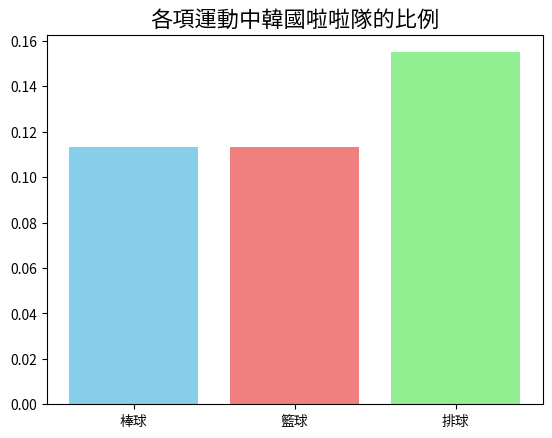

In [ ]:
#統計各球類韓職啦啦隊比例
baseball =(
(cheerleader_extract['來台應援球種'] == '棒球') |
(cheerleader_extract['來台應援球種'] == '棒球、籃球') |
(cheerleader_extract['來台應援球種'] == '棒球、籃球、排球')
).sum()
basketball = (
(cheerleader_extract['來台應援球種'] == '棒球、籃球')|
(cheerleader_extract['來台應援球種'] == '籃球')|
(cheerleader_extract['來台應援球種'] == '籃球、排球')|
(cheerleader_extract['來台應援球種'] == '棒球、籃球、排球')
).sum()
volleyball = (
(cheerleader_extract['來台應援球種'] == '籃球、排球')|
(cheerleader_extract['來台應援球種'] == '排球')|
(cheerleader_extract['來台應援球種'] == '棒球、籃球、排球')
).sum()
print(baseball)
print(basketball)
print(volleyball)

cheerleader_korean = pd.Series([19,23,11], index =['棒球','籃球','排球'])
cheerleader_all = pd.Series([168,203,71], index =['棒球','籃球','排球'])
korean_rate = pd.Series(cheerleader_korean/cheerleader_all, index =['棒球','籃球','排球'])
print(korean_rate)

#製圖
plt.bar(korean_rate.index, korean_rate.values,color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('各項運動中韓國啦啦隊的比例', fontsize=16)
plt.show()

經營Youtube
1    21
0    16
Name: count, dtype: int64
開直播
1    23
0    14
Name: count, dtype: int64


/tmp/ipython-input-1431454589.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=youtube, ax=axs[0], palette=['#6495ED'])
/tmp/ipython-input-1431454589.py:9: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x=youtube, ax=axs[0], palette=['#6495ED'])
/tmp/ipython-input-1431454589.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x= live, ax = axs[1], palette=['#FF6347'])
/tmp/ipython-input-1431454589.py:13: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x= live, ax = axs[1], palette=['#FF6347']

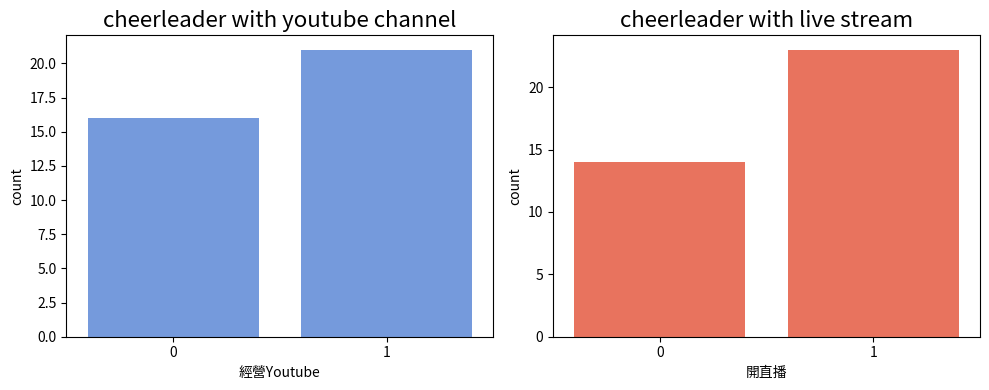

In [ ]:
#計算有youtube頻道以及直播比例
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
youtube = cheerleader_extract['經營Youtube']
live = cheerleader_extract['開直播']
print(youtube.value_counts())
print(live.value_counts())

# 在第一個子圖 (axs[0]) 上繪圖
sns.countplot(x=youtube, ax=axs[0], palette=['#6495ED'])
axs[0].set_title('cheerleader with youtube channel',fontsize = 16)

# 在第二個子圖 (axs[1]) 上繪圖
sns.countplot(x= live, ax = axs[1], palette=['#FF6347'])
axs[1].set_title('cheerleader with live stream',fontsize = 16)

# 自動调整子圖參數，使之填充整個 figure 區域，並避免重疊
plt.tight_layout()

# 顯示圖表
plt.show()